<a href="https://colab.research.google.com/github/hpatel-27/DataScience_CourseProject/blob/main/mkang8HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## HW 7
Author: Minji Kang <br>
Date: 4/14/2025 <br>
Description: Fitting a KNN model to explore if any locations consistently grow players with above-average or below-average advanced NBA metrics.  <br>

In [51]:
# importing necessary libraries, other imports are scattered throughout the notebook
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import seaborn as sns
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [52]:
# Read in the merged dataset
mergedDF = pd.read_csv("https://raw.githubusercontent.com/hpatel-27/DataScience_CourseProject/refs/heads/main/datasets/merged_playerStats.csv", index_col=0)

# Read in players dataset
players = pd.read_csv("https://raw.githubusercontent.com/hpatel-27/DataScience_CourseProject/refs/heads/main/datasets/Players.csv", index_col=0)

In [53]:
# getting birth location from original players dataset since it was dropped for merged dataset
locationDF = players[['birth_state']]
# setting index as player name
locationDF.index = players['Player']
# adding advanced metrics and college name
locationDF = locationDF.join(mergedDF[['college', 'BPM', 'VORP', 'WS']])
locationDF

,birth_state,college,BPM,VORP,WS
Player,,,,,
Curly Armstrong,NaN,Indiana University,NaN,NaN,2.408911
Cliff Barker,Indiana,University of Kentucky,NaN,NaN,0.677852
Leo Barnhorst,NaN,University of Notre Dame,NaN,NaN,NaN
Ed Bartels,NaN,North Carolina State University,NaN,NaN,-0.538298
Ralph Beard,Kentucky,University of Kentucky,NaN,NaN,5.690476
...,...,...,...,...,...
Troy Williams,South Carolina,South Carolina State University,-2.76,-0.09,0.180000
Kyle Wiltjer,Oregon,Gonzaga University,-4.00,0.00,0.000000
Stephen Zimmerman,Tennessee,"University of Nevada, Las Vegas",-7.30,-0.10,0.000000


In [54]:
# dropping college column
birthDF = locationDF.drop(columns=['college'])
# dropping row if birth location is not available
birthDF = birthDF.dropna(subset=['birth_state'])
# dropping row if WS or VORP is not available
birthDF = birthDF.dropna(subset=['VORP', 'WS'])
birthDF.reset_index(inplace=True)
# dropping row if less than 15 players born at that state
birthDF = birthDF.groupby('birth_state').filter(lambda x: len(x) > 15)
birthDF

,Player,birth_state,BPM,VORP,WS
0,Mike Bantom,Pennsylvania,-0.398081,0.888166,3.449893
1,Ron Behagen,New York,-1.990476,0.080745,2.102692
2,Dennis Bell,Ohio,-4.320635,-0.247619,0.082540
3,Jim Brewer,Illinois,0.358238,1.173819,3.056066
4,Allan Bristow,Virginia,-0.390278,0.743981,2.777932
...,...,...,...,...,...
2829,Isaiah Whitehead,New York,-4.900000,-1.200000,-0.800000
2830,Troy Williams,South Carolina,-2.760000,-0.090000,0.180000
2831,Kyle Wiltjer,Oregon,-4.000000,0.000000,0.000000
2832,Stephen Zimmerman,Tennessee,-7.300000,-0.100000,0.000000


In [55]:
# dropping birth state column
collegeDF = locationDF.drop(columns=['birth_state'])
# dropping row if college is not available
collegeDF = collegeDF.dropna(subset=['college'])
# dropping row if WS or VORP is not available
collegeDF = collegeDF.dropna(subset=['VORP', 'WS'])
collegeDF.reset_index(inplace=True)
# dropping row if less than 15 players at college
collegeDF = collegeDF.groupby('college').filter(lambda x: len(x) > 15)
collegeDF

,Player,college,BPM,VORP,WS
1,Ron Behagen,University of Minnesota,-1.990476,0.080745,2.102692
3,Jim Brewer,University of Minnesota,0.358238,1.173819,3.056066
5,John Brown,University of Missouri,-1.900193,0.213127,2.367568
7,Bill Chamberlain,University of North Carolina,-0.100000,0.200000,0.500000
11,Mel Davis,St. John's University,-5.300000,-0.600000,0.007317
...,...,...,...,...,...
2617,Tyler Ulis,University of Kentucky,-4.000000,-0.600000,0.700000
2618,Jarrod Uthoff,University of Iowa,-1.400000,0.000000,0.200000
2619,Denzel Valentine,Michigan State University,-2.800000,-0.200000,0.600000
2621,Okaro White,Florida State University,-2.100000,0.000000,0.600000


Text(0.5, 1.0, 'Birth State vs. WS and VORP')

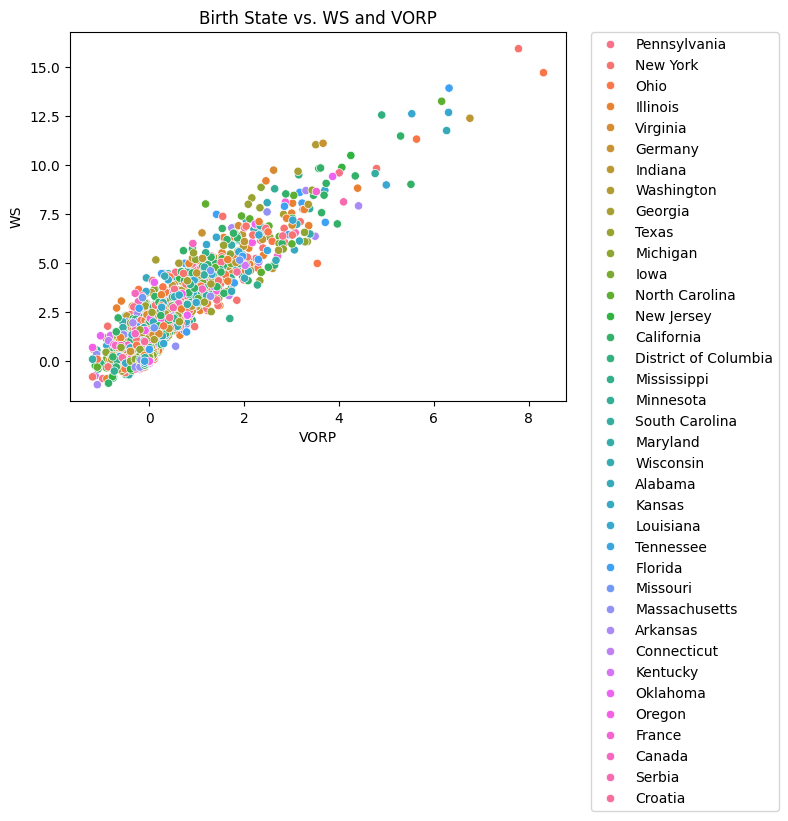

In [56]:
# plotting a scatterplot using VORP and WS and coloring it by the birth states
ax = sns.scatterplot(x=birthDF['VORP'], y=birthDF['WS'], hue=birthDF['birth_state'])
# moving legend to the right to not cover up plot
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title('Birth State vs. WS and VORP')

Text(0.5, 1.0, 'College vs. WS and VORP')

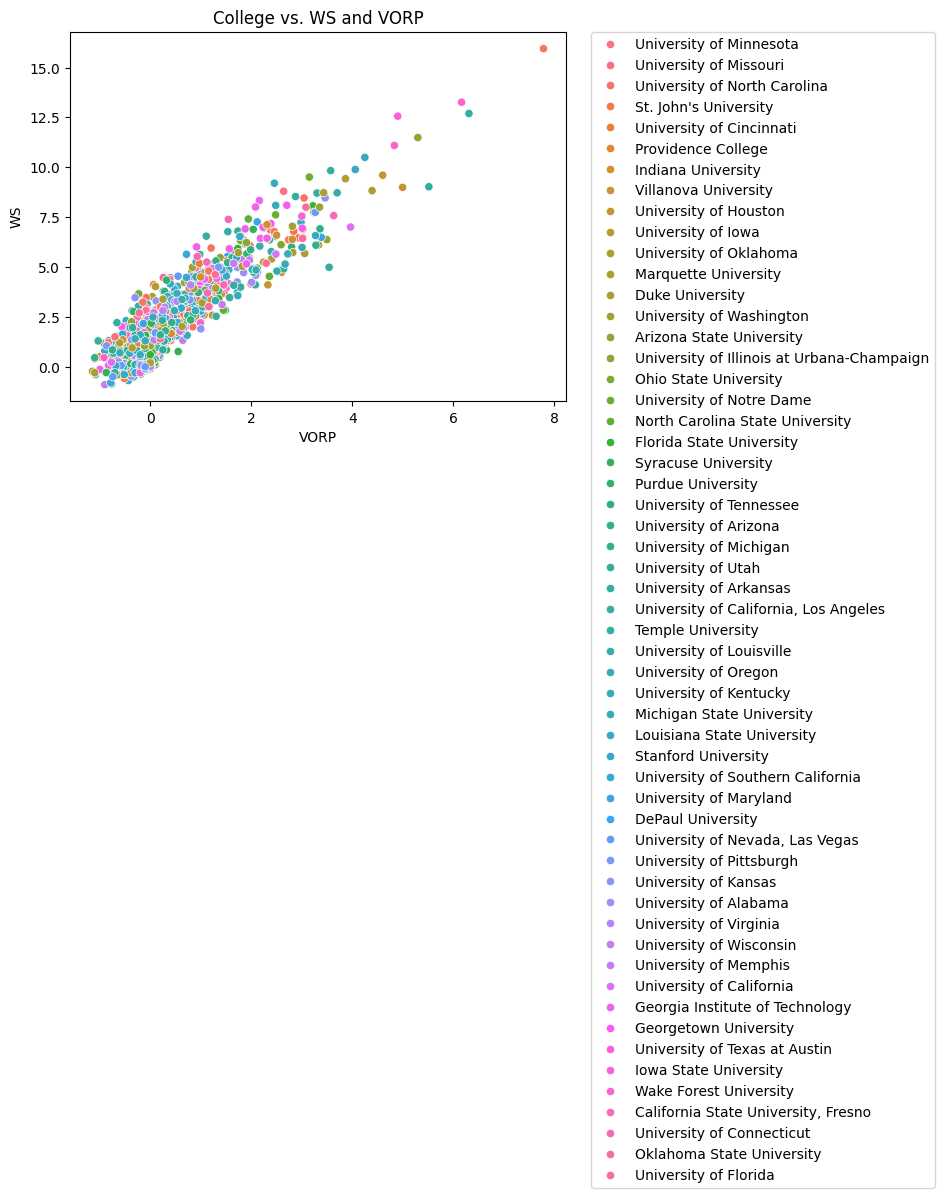

In [57]:
# plotting a scatterplot using VORP and WS and coloring it by the colleges
ax = sns.scatterplot(x=collegeDF['VORP'], y=collegeDF['WS'], hue=collegeDF['college'])
# moving legend to the right to not cover up plot
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title('College vs. WS and VORP')

In [58]:
# normalizing data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

### KNN for Birth State

In [59]:
# birth state KNN
X = birthDF[['BPM', 'VORP', 'WS']].values
y = birthDF['birth_state'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [60]:
# first value of k to try
k = 10

In [61]:
# fitting KNN
sKNN = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
sKNN.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=10)

In [62]:
# predicting birth state with 10 nearest neighbors
y_pred = sKNN.predict(X_test)

In [63]:
# getting accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy without scaling:", accuracy)

Accuracy without scaling: 0.07482993197278912


In [64]:
# scaling features
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# fitting KNN
sKNN = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
sKNN.fit(X_train, y_train)
# predicting birth state with 10 nearest neighbors
y_pred = sKNN.predict(X_test)
# getting accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with scaling:", accuracy)

Accuracy with scaling: 0.08163265306122448


### Cross Validation for Birth State KNN

In [65]:
# checking which value of k between 1 and 50 is most accurate
k_values = list(range(1, 51))
scores = []

# appending accuracy scores into a list
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    scores.append([k, cv_scores.mean()])

# making scores into a dataframe
scores = pd.DataFrame(scores, columns=['K', 'Accuracy'])
scores

,K,Accuracy
0,1,0.051982
1,2,0.053155
2,3,0.060751
3,4,0.056660
4,5,0.061912
5,6,0.062495
6,7,0.067756
7,8,0.071857
8,9,0.068353
9,10,0.073613


k = 45 seems to be most accurate

Text(0.5, 1.0, 'Accuracy vs. K for Birth States')

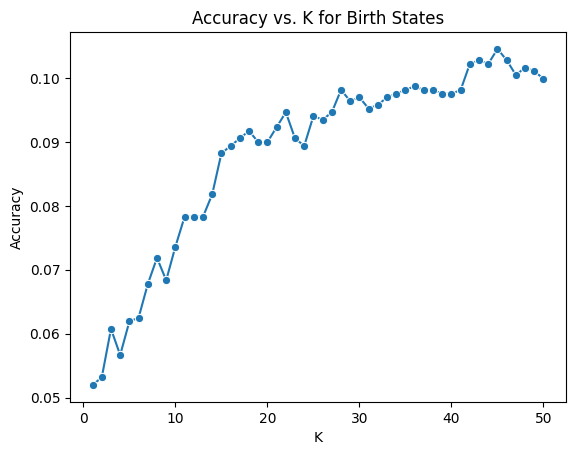

In [66]:
# plotting accuracy vs k
sns.lineplot(x=k_values, y=scores['Accuracy'], marker = 'o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. K for Birth States')

In [67]:
# fitting KNN
sKNN = KNeighborsClassifier(n_neighbors=45, metric="euclidean")
sKNN.fit(X_train, y_train)
# predicting birth state with 45 nearest neighbors
y_pred = sKNN.predict(X_test)
# getting accuracy
accuracy = accuracy_score(y_test, y_pred)
# getting precision
precision = precision_score(y_test, y_pred, average='macro', zero_division=np.nan)
# getting recall
recall = recall_score(y_test, y_pred, average='macro')
print("Accuracy with scaling and cross validation:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy with scaling and cross validation: 0.10884353741496598
Precision: 0.03228918179436406
Recall: 0.027638115534008783


### KNN for Colleges

In [68]:
# college KNN
X = collegeDF[['BPM', 'VORP', 'WS']].values
y = collegeDF['college'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [69]:
# first value of k to try
k = 10

In [70]:
# fitting KNN
cKNN = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
cKNN.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=10)

In [71]:
# predicting classification of colleges
y_pred = cKNN.predict(X_test)

In [72]:
# predicting college with 10 nearest neighbors
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy without scaling:", accuracy)

Accuracy without scaling: 0.021929824561403508


In [73]:
# scaling features
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# fitting KNN
cKNN = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
cKNN.fit(X_train, y_train)
# predicting birth state with 10 nearest neighbors
y_pred = cKNN.predict(X_test)
# getting accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with scaling:", accuracy)

Accuracy with scaling: 0.015350877192982455


### Cross Validation for College KNN

In [74]:
# checking which value of k between 1 and 50 is most accurate
k_values = list(range(1, 50))
scores = []

# appending accuracy scores into a list
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    scores.append([k, cv_scores.mean()])

# making scores into a dataframe
scores = pd.DataFrame(scores, columns=['K', 'Accuracy'])
scores

,K,Accuracy
0,1,0.023558
1,2,0.020750
2,3,0.012255
3,4,0.015077
4,5,0.013199
5,6,0.019785
6,7,0.022611
7,8,0.022606
8,9,0.023549
9,10,0.023558


k = 37 seems to be most accurate

Text(0.5, 1.0, 'Accuracy vs. K for Colleges')

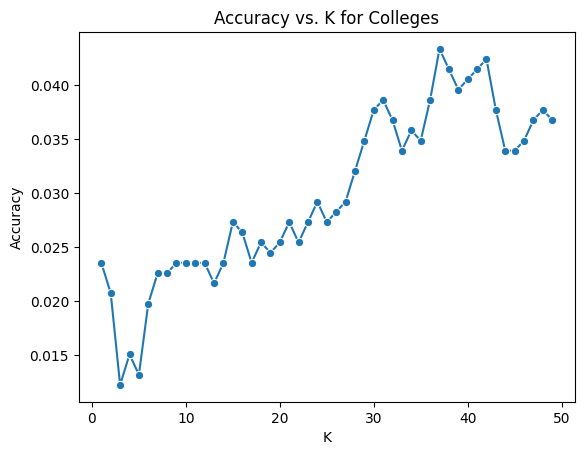

In [75]:
# plotting accuracy vs k
sns.lineplot(x=k_values, y=scores['Accuracy'], marker = 'o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. K for Colleges')

In [76]:
# fitting KNN
cKNN = KNeighborsClassifier(n_neighbors=37, metric="euclidean")
cKNN.fit(X_train, y_train)
# predicting birth state with 37 nearest neighbors
y_pred = cKNN.predict(X_test)
# getting accuracy
accuracy = accuracy_score(y_test, y_pred)
# getting precision
precision = precision_score(y_test, y_pred, average='macro', zero_division=np.nan)
# getting recall
recall = recall_score(y_test, y_pred, average='macro')
print("Accuracy with scaling and cross validation:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy with scaling and cross validation: 0.03070175438596491
Precision: 0.016480816151671653
Recall: 0.023697024900233458
